# 🚗 CrashLens — Severity Estimation Model
## Experiment 05 · Loss Function Study

---

| Sub-experiment | Loss Function | Key change |
|---|---|---|
| **exp05A** | CrossEntropyLoss | Control — baseline |
| **exp05B** | Weighted CrossEntropyLoss | Class-frequency weights from train set |
| **exp05C** | Focal Loss (γ=2) | Focus on hard/misclassified samples |
| **exp05D** | Label Smoothing CE (ε=0.1) | Reduce overconfidence, improve generalisation |

---

### Fixed across all sub-experiments
| Setting | Value |
|---|---|
| Model | ResNet50 (ImageNet pretrained) |
| Backbone | Fully trainable |
| Optimizer | AdamW ← exp02E |
| Learning rate | 1e-4 |
| Weight decay | 1e-2 |
| Batch size | 32 |
| Input size | 224×224 |
| Augmentation | Stronger ← exp03B |
| Max epochs | 50 |
| Early stopping | patience = 7 |
| Seed | 42 |
| Dataset split | Same manifest as exp00–exp04 |

### Known results so far
| Experiment | Key change | Test Macro F1 |
|---|---|---|
| exp00 | Adam 1e-3, current aug | 0.7609 |
| exp01 | Adam 1e-4, full fine-tune | 0.9100 |
| exp02E | AdamW 1e-4 bs=32 | ~0.91 |
| exp03B | Stronger augmentation | 0.9018 |
| exp04 winner | Best input size | *(carry forward)* |

### Evaluation protocol
- **Val set**: ranks all sub-experiments; used for winner selection
- **Test set**: evaluated exactly once on the val-selected winner (Section 11)


## 📁 Section 1 — Google Drive Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

DRIVE_ROOT    = '/content/drive/MyDrive/Severity_Model'
EXP_NAME      = 'exp05_loss_function'
EXP_DIR       = os.path.join(DRIVE_ROOT, EXP_NAME)
MANIFEST_PATH = os.path.join(DRIVE_ROOT, 'split_manifest.json')

SUB_EXPS = ['exp05A_cross_entropy','exp05B_weighted_ce','exp05C_focal_loss','exp05D_label_smoothing']
for sub in SUB_EXPS:
    for folder in ['weights','results','graphs','predictions']:
        os.makedirs(os.path.join(EXP_DIR, sub, folder), exist_ok=True)

print('✅ Drive mounted and experiment folders ready.')
print(f'   Experiment root : {EXP_DIR}')
print(f'   Sub-experiments : {SUB_EXPS}')


Mounted at /content/drive
✅ Drive mounted and experiment folders ready.
   Experiment root : /content/drive/MyDrive/Severity_Model/exp05_loss_function
   Sub-experiments : ['exp05A_cross_entropy', 'exp05B_weighted_ce', 'exp05C_focal_loss', 'exp05D_label_smoothing']


## ⚙️ Section 2 — Shared Configuration & Sub-experiment Definitions

In [2]:
CLASSES = ['minor', 'moderate', 'severe']

BASE_CONFIG = {
    'model_name':'ResNet50','classes':CLASSES,
    'raw_data_dir':'/content/merged_severity_dataset',
    'input_size':224,'epochs':50,'batch_size':32,'num_workers':2,'seed':42,
    'early_stop_patience':7,'pretrained':True,'freeze_backbone':False,
    'optimizer':'AdamW','learning_rate':1e-4,'weight_decay':1e-2,
    # Augmentation — stronger from exp03B
    'aug_hflip_p':0.5,'aug_brightness':0.2,'aug_contrast':0.2,
    'aug_saturation':0.1,'aug_hue':0.05,'aug_rotation':15,
    'aug_translate':(0.1,0.1),'aug_scale':(0.9,1.1),'aug_grayscale_p':0.1,
    'save_metric':'macro_f1',
}

SUB_CONFIGS = {
    'exp05A_cross_entropy' : {'loss_name':'CrossEntropy',     'note':'Baseline — standard CE'},
    'exp05B_weighted_ce'   : {'loss_name':'WeightedCE',       'note':'Class-frequency weights from train set'},
    'exp05C_focal_loss'    : {'loss_name':'FocalLoss(g=2)',   'focal_gamma':2.0, 'note':'Focus on hard samples'},
    'exp05D_label_smoothing':{'loss_name':'LabelSmoothing(e=0.1)','label_smoothing':0.1,'note':'Reduce overconfidence'},
}

import json
print('✅ Configurations set.')
print(f'   {"ID":30s}  {"Loss":25s}  Note')
print('   '+'-'*80)
for sid, cfg in SUB_CONFIGS.items():
    print(f'   {sid:30s}  {cfg["loss_name"]:25s}  {cfg["note"]}')


✅ Configurations set.
   ID                              Loss                       Note
   --------------------------------------------------------------------------------
   exp05A_cross_entropy            CrossEntropy               Baseline — standard CE
   exp05B_weighted_ce              WeightedCE                 Class-frequency weights from train set
   exp05C_focal_loss               FocalLoss(g=2)             Focus on hard samples
   exp05D_label_smoothing          LabelSmoothing(e=0.1)      Reduce overconfidence


## 🔧 Section 3 — Environment Setup

In [3]:
import json,random,shutil,numpy as np,torch,torch.nn as nn,torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms,models
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report,confusion_matrix,
    ConfusionMatrixDisplay,f1_score,precision_recall_fscore_support)
import pandas as pd,warnings
warnings.filterwarnings('ignore')

SEED=BASE_CONFIG['seed']
random.seed(SEED);np.random.seed(SEED)
torch.manual_seed(SEED);torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True;torch.backends.cudnn.benchmark=False

DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Seed={SEED}  Device={DEVICE}')
if DEVICE.type=='cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


✅ Seed=42  Device=cuda
   GPU : NVIDIA L4
   VRAM: 23.7 GB


## 📦 Section 4 — Dataset: Extract & Reuse Split

In [4]:
import zipfile
ZIP_PATH='/content/drive/MyDrive/Severity_Model/merged_severity_dataset.zip'
EXTRACT_PATH='/content/merged_severity_dataset'
if not os.path.exists(EXTRACT_PATH):
    print('📦 Extracting...')
    with zipfile.ZipFile(ZIP_PATH,'r') as zf: zf.extractall(EXTRACT_PATH)
    print(f'✅ Extracted to {EXTRACT_PATH}')
else: print(f'✅ Dataset already at {EXTRACT_PATH}')


📦 Extracting...
✅ Extracted to /content/merged_severity_dataset


In [5]:
if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(f'Manifest not found at {MANIFEST_PATH}. Run exp00 first.')
with open(MANIFEST_PATH,'r') as f: manifest=json.load(f)
print('✅ Manifest loaded — reusing exp00 split.')

RAW_DATA='/content/merged_severity_dataset'; SPLIT_DIR='/content/dataset_split'

def remap(path):
    parts=path.replace('\\','/').split('/')
    for i,part in enumerate(parts):
        if part in ('train','val','test'): return os.path.join(RAW_DATA,*parts[i:])
    return path

for split in ['train','val','test']:
    for cls in CLASSES:
        dest=os.path.join(SPLIT_DIR,split,cls); os.makedirs(dest,exist_ok=True)
        for src in manifest[split][cls]:
            src=remap(src); dst=os.path.join(dest,os.path.basename(src))
            if not os.path.exists(dst): shutil.copy2(src,dst)

TRAIN_DIR=os.path.join(SPLIT_DIR,'train')
VAL_DIR  =os.path.join(SPLIT_DIR,'val')
TEST_DIR =os.path.join(SPLIT_DIR,'test')
print('\n✅ Split folders ready:')
for split in ['train','val','test']:
    total=sum(len(manifest[split][cls]) for cls in CLASSES)
    bd='  '.join(f'{c}={len(manifest[split][c])}' for c in CLASSES)
    print(f'   {split:6s}: {total} images  |  {bd}')


✅ Manifest loaded — reusing exp00 split.

✅ Split folders ready:
   train : 3475 images  |  minor=1184  moderate=1133  severe=1158
   val   : 745 images  |  minor=254  moderate=243  severe=248
   test  : 746 images  |  minor=254  moderate=243  severe=249


## 🔍 Section 5 — Dataset Verification

In [6]:
for split_name,sdir in [('Train',TRAIN_DIR),('Val',VAL_DIR),('Test',TEST_DIR)]:
    counts={cls:len([f for f in os.listdir(os.path.join(sdir,cls)) if f.lower().endswith(('.jpg','.jpeg','.png'))]) for cls in CLASSES}
    print(f'📊 {split_name}: '+' | '.join(f'{c}={n}' for c,n in counts.items())+f' | TOTAL={sum(counts.values())}')


📊 Train: minor=1125 | moderate=1078 | severe=1100 | TOTAL=3303
📊 Val: minor=250 | moderate=242 | severe=248 | TOTAL=740
📊 Test: minor=252 | moderate=241 | severe=249 | TOTAL=742


## 🔄 Section 6 — Transforms & Class Weights

In [7]:
IMAGENET_MEAN=[0.485,0.456,0.406]; IMAGENET_STD=[0.229,0.224,0.225]
SZ=BASE_CONFIG['input_size']

TRAIN_TF=transforms.Compose([
    transforms.Resize((SZ,SZ)),
    transforms.RandomHorizontalFlip(p=BASE_CONFIG['aug_hflip_p']),
    transforms.ColorJitter(brightness=BASE_CONFIG['aug_brightness'],contrast=BASE_CONFIG['aug_contrast'],
                           saturation=BASE_CONFIG['aug_saturation'],hue=BASE_CONFIG['aug_hue']),
    transforms.RandomRotation(degrees=BASE_CONFIG['aug_rotation']),
    transforms.RandomAffine(degrees=0,translate=BASE_CONFIG['aug_translate'],scale=BASE_CONFIG['aug_scale']),
    transforms.RandomGrayscale(p=BASE_CONFIG['aug_grayscale_p']),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),
])
VAL_TF=transforms.Compose([
    transforms.Resize((SZ,SZ)),transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN,std=IMAGENET_STD),
])

# Class weights from training set ONLY — used by exp05B
_counts=[len([f for f in os.listdir(os.path.join(TRAIN_DIR,c))
              if f.lower().endswith(('.jpg','.jpeg','.png'))]) for c in CLASSES]
_total=sum(_counts)
CLASS_WEIGHTS=torch.tensor([_total/(_c*len(CLASSES)) for _c in _counts],dtype=torch.float).to(DEVICE)
print('✅ Transforms defined (stronger aug from exp03B).')
print(f'   Class weights (train-only): '+' | '.join(f'{c}={w:.4f}' for c,w in zip(CLASSES,CLASS_WEIGHTS.cpu())))


✅ Transforms defined (stronger aug from exp03B).
   Class weights (train-only): minor=0.9787 | moderate=1.0213 | severe=1.0009


## 🛠️ Section 7 — Loss Functions & Shared Helpers

In [8]:
# ── Focal Loss implementation ─────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.gamma=gamma; self.weight=weight; self.reduction=reduction
    def forward(self, inputs, targets):
        ce=nn.functional.cross_entropy(inputs,targets,weight=self.weight,reduction='none')
        pt=torch.exp(-ce)
        focal=((1-pt)**self.gamma)*ce
        return focal.mean() if self.reduction=='mean' else focal.sum()


def build_criterion(sub_id):
    cfg=SUB_CONFIGS[sub_id]
    name=cfg['loss_name']
    if 'CrossEntropy'   == name: return nn.CrossEntropyLoss()
    if 'WeightedCE'     == name: return nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)
    if name.startswith('FocalLoss'): return FocalLoss(gamma=cfg.get('focal_gamma',2.0))
    if name.startswith('LabelSmoothing'): return nn.CrossEntropyLoss(label_smoothing=cfg.get('label_smoothing',0.1))
    raise ValueError(f'Unknown loss: {name}')


# ── Standard helpers (identical structure to exp03/04) ────────────────────────
NUM_CLASSES=len(CLASSES)

def seed_worker(wid):
    s=torch.initial_seed()%2**32; np.random.seed(s); random.seed(s)

def build_dataloaders():
    g=torch.Generator(); g.manual_seed(BASE_CONFIG['seed'])
    bs=BASE_CONFIG['batch_size']
    tr=datasets.ImageFolder(root=TRAIN_DIR,transform=TRAIN_TF)
    vl=datasets.ImageFolder(root=VAL_DIR,  transform=VAL_TF)
    te=datasets.ImageFolder(root=TEST_DIR, transform=VAL_TF)
    kw=dict(num_workers=BASE_CONFIG['num_workers'],pin_memory=(DEVICE.type=='cuda'))
    return (DataLoader(tr,batch_size=bs,shuffle=True,worker_init_fn=seed_worker,generator=g,**kw),
            DataLoader(vl,batch_size=bs,shuffle=False,**kw),
            DataLoader(te,batch_size=bs,shuffle=False,**kw),tr,vl,te)

def build_model():
    m=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    m.fc=nn.Linear(m.fc.in_features,NUM_CLASSES); return m.to(DEVICE)

def build_optimizer(model):
    return optim.AdamW(model.parameters(),lr=BASE_CONFIG['learning_rate'],weight_decay=BASE_CONFIG['weight_decay'])

def run_epoch(model,loader,criterion,optimizer,phase='train'):
    is_train=(phase=='train')
    model.train() if is_train else model.eval()
    running_loss=0.0; all_preds=[]; all_labels=[]
    with torch.set_grad_enabled(is_train):
        for images,labels in loader:
            images,labels=images.to(DEVICE),labels.to(DEVICE)
            if is_train: optimizer.zero_grad()
            out=model(images); loss=criterion(out,labels)
            if is_train: loss.backward(); optimizer.step()
            running_loss+=loss.item()*images.size(0)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    n=len(loader.dataset)
    return (running_loss/n, np.mean(np.array(all_preds)==np.array(all_labels)),
            f1_score(all_labels,all_preds,average='macro',zero_division=0),all_labels,all_preds)

def save_checkpoint(model,optimizer,epoch,score,path):
    torch.save({'epoch':epoch,'model_state':model.state_dict(),
                'optimizer_state':optimizer.state_dict(),'best_macro_f1':score},path)

def denorm(t):
    m=torch.tensor(IMAGENET_MEAN).view(3,1,1); s=torch.tensor(IMAGENET_STD).view(3,1,1)
    return (t*s+m).clamp(0,1).permute(1,2,0).numpy()


def save_val_results(sub_id,model,val_loader,criterion,optimizer,history,best_epoch,best_val_f1):
    sub_dir=os.path.join(EXP_DIR,sub_id)
    results_dir=os.path.join(sub_dir,'results'); graphs_dir=os.path.join(sub_dir,'graphs')
    loss_name=SUB_CONFIGS[sub_id]['loss_name']

    actual_epochs=list(range(1,len(history['train_loss'])+1))
    fig,axes=plt.subplots(1,3,figsize=(18,5))
    fig.suptitle(f'{sub_id} ({loss_name}) — Training Curves',fontsize=13,fontweight='bold')
    for ax,(tr_k,vl_k),title in zip(axes,
        [('train_loss','val_loss'),('train_acc','val_acc'),('train_f1','val_f1')],
        ['Loss','Accuracy','Macro F1']):
        ax.plot(actual_epochs,history[tr_k],label='Train',color='steelblue')
        ax.plot(actual_epochs,history[vl_k],label='Val',  color='tomato')
        ax.axvline(best_epoch+1,color='gold',linestyle='--',label=f'Best (ep {best_epoch+1})')
        ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(graphs_dir,'training_curves.png'),dpi=150,bbox_inches='tight'); plt.show()

    _,_,_,val_labels,val_preds=run_epoch(model,val_loader,criterion,optimizer,phase='val')
    report=classification_report(val_labels,val_preds,target_names=CLASSES,digits=4)
    print(f'\n📋 {sub_id} — Classification Report (VAL SET):'); print(report)
    with open(os.path.join(results_dir,'val_classification_report.txt'),'w') as f:
        f.write(f'Sub-experiment: {sub_id}\nLoss: {loss_name}\n')
        f.write(f'Best epoch: {best_epoch+1}\nBest Val Macro F1: {best_val_f1:.4f}\n')
        f.write('NOTE: Test set reserved for winner only (Section 11)\n\n'); f.write(report)

    cm=confusion_matrix(val_labels,val_preds)
    fig,ax=plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(cm,display_labels=CLASSES).plot(ax=ax,cmap='Blues')
    ax.set_title(f'Confusion Matrix — {sub_id} (Val Set)',fontweight='bold')
    plt.savefig(os.path.join(results_dir,'val_confusion_matrix.png'),dpi=150,bbox_inches='tight'); plt.show()

    precision,recall,f1,support=precision_recall_fscore_support(val_labels,val_preds,average=None,labels=[0,1,2],zero_division=0)
    macro_p,macro_r,macro_f,_=precision_recall_fscore_support(val_labels,val_preds,average='macro',zero_division=0)
    rows=[{'class':cls,'precision':round(precision[i],4),'recall':round(recall[i],4),
           'f1':round(f1[i],4),'support':support[i]} for i,cls in enumerate(CLASSES)]
    rows.append({'class':'macro_avg','precision':round(macro_p,4),'recall':round(macro_r,4),'f1':round(macro_f,4),'support':sum(support)})
    pd.DataFrame(rows).to_csv(os.path.join(results_dir,'val_metrics.csv'),index=False)
    pd.DataFrame({'epoch':actual_epochs,**{k:history[k] for k in history}}).to_csv(
        os.path.join(results_dir,'training_history.csv'),index=False)
    print(f'✅ {sub_id} — val results saved to Drive.')
    return round(macro_f,4)


def run_final_test_eval(winner_id,winner_model,winner_optimizer,test_loader,criterion,test_ds):
    sub_dir=os.path.join(EXP_DIR,winner_id)
    results_dir=os.path.join(sub_dir,'results'); preds_dir=os.path.join(sub_dir,'predictions')
    loss_name=SUB_CONFIGS[winner_id]['loss_name']
    print(f'\n🏆 Final test evaluation — winner: {winner_id} ({loss_name})')
    print('   (Test set used for the first and only time)')
    _,_,_,final_labels,final_preds=run_epoch(winner_model,test_loader,criterion,winner_optimizer,phase='val')
    report=classification_report(final_labels,final_preds,target_names=CLASSES,digits=4)
    print(f'\n📋 {winner_id} — Classification Report (TEST SET):'); print(report)
    with open(os.path.join(results_dir,'test_classification_report.txt'),'w') as f:
        f.write(f'Winner: {winner_id}\nLoss: {loss_name}\nTest set size: {len(test_ds)}\n\n'); f.write(report)
    cm=confusion_matrix(final_labels,final_preds)
    fig,ax=plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(cm,display_labels=CLASSES).plot(ax=ax,cmap='Blues')
    ax.set_title(f'Confusion Matrix — {winner_id} (TEST SET — FINAL)',fontweight='bold')
    plt.savefig(os.path.join(results_dir,'test_confusion_matrix.png'),dpi=150,bbox_inches='tight'); plt.show()
    precision,recall,f1,support=precision_recall_fscore_support(final_labels,final_preds,average=None,labels=[0,1,2],zero_division=0)
    macro_p,macro_r,macro_f,_=precision_recall_fscore_support(final_labels,final_preds,average='macro',zero_division=0)
    rows=[{'class':cls,'precision':round(precision[i],4),'recall':round(recall[i],4),
           'f1':round(f1[i],4),'support':support[i]} for i,cls in enumerate(CLASSES)]
    rows.append({'class':'macro_avg','precision':round(macro_p,4),'recall':round(macro_r,4),'f1':round(macro_f,4),'support':sum(support)})
    pd.DataFrame(rows).to_csv(os.path.join(results_dir,'test_metrics.csv'),index=False)
    winner_model.eval(); imgs_shown,trues,pred_list,confs=[],[],[],[]
    with torch.no_grad():
        for images,labels in test_loader:
            out=winner_model(images.to(DEVICE)); probs=torch.softmax(out,dim=1).cpu()
            c,p=probs.max(dim=1)
            imgs_shown.extend(images); trues.extend(labels.numpy())
            pred_list.extend(p.numpy()); confs.extend(c.numpy())
            if len(imgs_shown)>=16: break
    fig,axes=plt.subplots(3,4,figsize=(14,10))
    fig.suptitle(f'Sample Predictions — {winner_id} (TEST SET — FINAL)',fontsize=13,fontweight='bold')
    for idx,ax in enumerate(axes.flat[:12]):
        img=denorm(imgs_shown[idx]); true=CLASSES[trues[idx]]; pred=CLASSES[pred_list[idx]]
        ax.imshow(img); ax.axis('off')
        ax.set_title(f'True: {true}\nPred: {pred} ({confs[idx]:.1%})',
                     color='green' if true==pred else 'red',fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(preds_dir,'test_sample_predictions.png'),dpi=150,bbox_inches='tight'); plt.show()
    print(f'\n✅ Final test results saved for {winner_id}.')
    return round(macro_f,4)


print('✅ All helpers defined.')
print('   build_criterion()     → returns the right loss for each sub-experiment')
print('   save_val_results()    → called after each sub-experiment (val only)')
print('   run_final_test_eval() → called ONCE on the winner in Section 11')


✅ All helpers defined.
   build_criterion()     → returns the right loss for each sub-experiment
   save_val_results()    → called after each sub-experiment (val only)
   run_final_test_eval() → called ONCE on the winner in Section 11


## 🏋️ Sections 8–10 — Training per Sub-experiment

Each sub-experiment: fresh ResNet50, AdamW, stronger aug, its own loss, patience=7, val-only evaluation.

> ⚠️ **Test set not touched until Section 11.**


## 🔵 Section 8 — exp05A · CrossEntropyLoss (Control)

In [9]:
SUB_ID='exp05A_cross_entropy'; sub_cfg=SUB_CONFIGS[SUB_ID]
with open(os.path.join(EXP_DIR,SUB_ID,'config.json'),'w') as f:
    json.dump({**BASE_CONFIG,**sub_cfg,'sub_id':SUB_ID},f,indent=2,default=str)

train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
model_05a=build_model(); optimizer_05a=build_optimizer(model_05a)
criterion=build_criterion(SUB_ID)
ckpt_path=os.path.join(EXP_DIR,SUB_ID,'weights','best_model.pth')

history_05a={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'train_f1':[],'val_f1':[]}
best_val_f1_05a=0.0; best_epoch_05a=0; patience_count=0
PATIENCE=BASE_CONFIG['early_stop_patience']; EPOCHS=BASE_CONFIG['epochs']

print(f'🚀 {SUB_ID} | loss: {sub_cfg["loss_name"]}')
print(f'{"Ep":>4}  {"T-Loss":>8}  {"T-F1":>7}  {"V-Loss":>8}  {"V-F1":>7}  {"Pat":>4}')
print('-'*50)

for epoch in range(EPOCHS):
    tr_loss,tr_acc,tr_f1,_,_=run_epoch(model_05a,train_loader,criterion,optimizer_05a,'train')
    vl_loss,vl_acc,vl_f1,_,_=run_epoch(model_05a,val_loader,  criterion,optimizer_05a,'val')
    for k,v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
                   [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]): history_05a[k].append(v)
    if vl_f1>best_val_f1_05a: best_val_f1_05a=vl_f1; best_epoch_05a=epoch; patience_count=0; save_checkpoint(model_05a,optimizer_05a,epoch,best_val_f1_05a,ckpt_path); flag='⭐'
    else: patience_count+=1; flag=''
    print(f'{epoch+1:4d}  {tr_loss:8.4f}  {tr_f1:7.4f}  {vl_loss:8.4f}  {vl_f1:7.4f}  {patience_count:4d}  {flag}')
    if patience_count>=PATIENCE: print(f'⏹️ Early stopping at epoch {epoch+1}'); break

print(f'\n✅ {SUB_ID} done. Best val F1: {best_val_f1_05a:.4f} (epoch {best_epoch_05a+1})')


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


🚀 exp05A_cross_entropy | loss: CrossEntropy
  Ep    T-Loss     T-F1    V-Loss     V-F1   Pat
--------------------------------------------------
   1    0.6422   0.7078    0.5735   0.7504     0  ⭐
   2    0.4906   0.7961    0.5027   0.7692     0  ⭐
   3    0.3840   0.8477    0.4453   0.8257     0  ⭐
   4    0.3286   0.8708    0.4728   0.8188     1  
   5    0.2483   0.9081    0.5470   0.8084     2  
   6    0.2436   0.9073    0.5273   0.8006     3  
   7    0.1835   0.9341    0.4425   0.8799     0  ⭐
   8    0.1985   0.9258    0.4288   0.8721     1  
   9    0.1499   0.9446    0.4978   0.8712     2  
  10    0.1551   0.9422    0.5255   0.8641     3  
  11    0.1367   0.9474    0.4667   0.8699     4  
  12    0.1329   0.9532    0.5074   0.8650     5  
  13    0.1230   0.9587    0.5082   0.8697     6  
  14    0.1287   0.9526    0.4984   0.8842     0  ⭐
  15    0.1382   0.9465    0.5415   0.8761     1  
  16    0.1026   0.9643    0.4988   0.8734     2  
  17    0.0857   0.9705    0.5303  

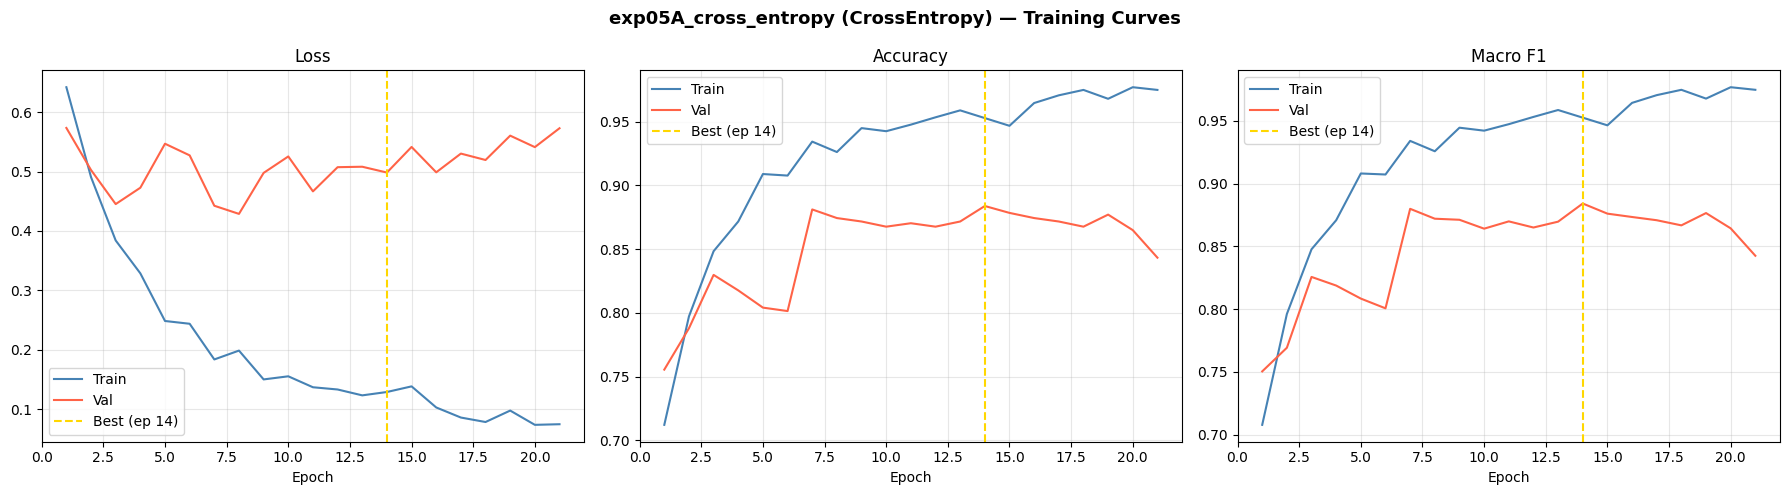


📋 exp05A_cross_entropy — Classification Report (VAL SET):
              precision    recall  f1-score   support

       minor     0.8945    0.9160    0.9051       250
    moderate     0.8093    0.8595    0.8337       242
      severe     0.9559    0.8750    0.9137       248

    accuracy                         0.8838       740
   macro avg     0.8866    0.8835    0.8842       740
weighted avg     0.8873    0.8838    0.8846       740



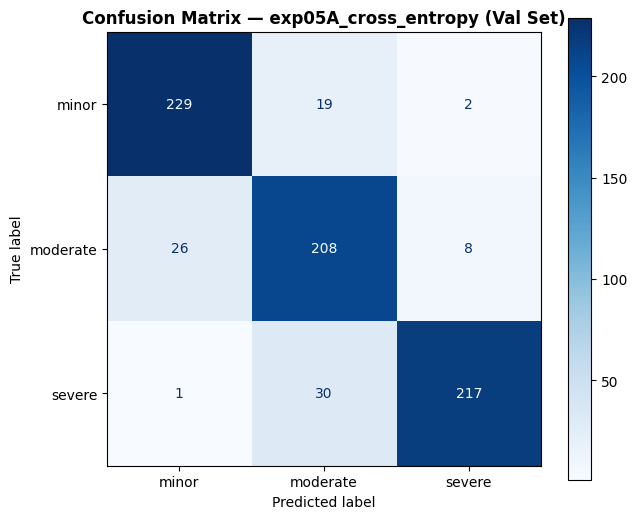

✅ exp05A_cross_entropy — val results saved to Drive.
   Val Macro F1: 0.8842


In [10]:
ckpt=torch.load(os.path.join(EXP_DIR,'exp05A_cross_entropy','weights','best_model.pth'),map_location=DEVICE)
model_05a.load_state_dict(ckpt['model_state'])
train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
val_f1_05a=save_val_results('exp05A_cross_entropy',model_05a,val_loader,build_criterion('exp05A_cross_entropy'),optimizer_05a,history_05a,best_epoch_05a,best_val_f1_05a)
print(f'   Val Macro F1: {val_f1_05a}')


## 🟢 Section 9 — exp05B · Weighted CrossEntropyLoss

In [11]:
SUB_ID='exp05B_weighted_ce'; sub_cfg=SUB_CONFIGS[SUB_ID]
with open(os.path.join(EXP_DIR,SUB_ID,'config.json'),'w') as f:
    json.dump({**BASE_CONFIG,**sub_cfg,'sub_id':SUB_ID},f,indent=2,default=str)

train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
model_05b=build_model(); optimizer_05b=build_optimizer(model_05b)
criterion=build_criterion(SUB_ID)
ckpt_path=os.path.join(EXP_DIR,SUB_ID,'weights','best_model.pth')

history_05b={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'train_f1':[],'val_f1':[]}
best_val_f1_05b=0.0; best_epoch_05b=0; patience_count=0
PATIENCE=BASE_CONFIG['early_stop_patience']; EPOCHS=BASE_CONFIG['epochs']

print(f'🚀 {SUB_ID} | loss: {sub_cfg["loss_name"]}')
print(f'{"Ep":>4}  {"T-Loss":>8}  {"T-F1":>7}  {"V-Loss":>8}  {"V-F1":>7}  {"Pat":>4}')
print('-'*50)

for epoch in range(EPOCHS):
    tr_loss,tr_acc,tr_f1,_,_=run_epoch(model_05b,train_loader,criterion,optimizer_05b,'train')
    vl_loss,vl_acc,vl_f1,_,_=run_epoch(model_05b,val_loader,  criterion,optimizer_05b,'val')
    for k,v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
                   [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]): history_05b[k].append(v)
    if vl_f1>best_val_f1_05b: best_val_f1_05b=vl_f1; best_epoch_05b=epoch; patience_count=0; save_checkpoint(model_05b,optimizer_05b,epoch,best_val_f1_05b,ckpt_path); flag='⭐'
    else: patience_count+=1; flag=''
    print(f'{epoch+1:4d}  {tr_loss:8.4f}  {tr_f1:7.4f}  {vl_loss:8.4f}  {vl_f1:7.4f}  {patience_count:4d}  {flag}')
    if patience_count>=PATIENCE: print(f'⏹️ Early stopping at epoch {epoch+1}'); break

print(f'\n✅ {SUB_ID} done. Best val F1: {best_val_f1_05b:.4f} (epoch {best_epoch_05b+1})')


🚀 exp05B_weighted_ce | loss: WeightedCE
  Ep    T-Loss     T-F1    V-Loss     V-F1   Pat
--------------------------------------------------
   1    0.6547   0.7028    0.6562   0.7082     0  ⭐
   2    0.4887   0.7936    0.5541   0.7629     0  ⭐
   3    0.3879   0.8483    0.4792   0.8000     0  ⭐
   4    0.3295   0.8749    0.5035   0.8131     0  ⭐
   5    0.2668   0.8945    0.5401   0.8282     0  ⭐
   6    0.2373   0.9118    0.7349   0.7357     1  
   7    0.2172   0.9235    0.4477   0.8779     0  ⭐
   8    0.1856   0.9339    0.4741   0.8708     1  
   9    0.1543   0.9455    0.6391   0.8371     2  
  10    0.1494   0.9423    0.5242   0.8678     3  
  11    0.1437   0.9476    0.5251   0.8588     4  
  12    0.1414   0.9477    0.4886   0.8639     5  
  13    0.1233   0.9584    0.4674   0.8800     0  ⭐
  14    0.1579   0.9415    0.4219   0.8737     1  
  15    0.1237   0.9552    0.5276   0.8589     2  
  16    0.0973   0.9667    0.5417   0.8625     3  
  17    0.0772   0.9729    0.4925   0

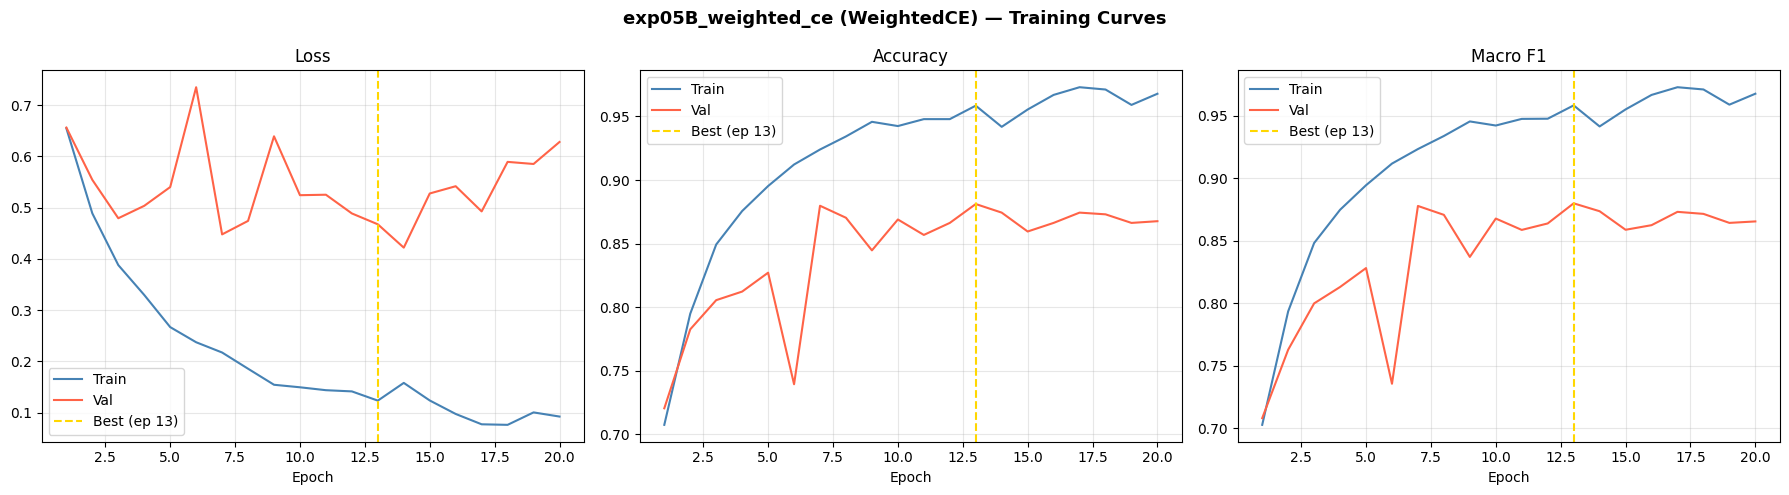


📋 exp05B_weighted_ce — Classification Report (VAL SET):
              precision    recall  f1-score   support

       minor     0.8694    0.9320    0.8996       250
    moderate     0.8515    0.8058    0.8280       242
      severe     0.9218    0.9032    0.9124       248

    accuracy                         0.8811       740
   macro avg     0.8809    0.8803    0.8800       740
weighted avg     0.8811    0.8811    0.8805       740



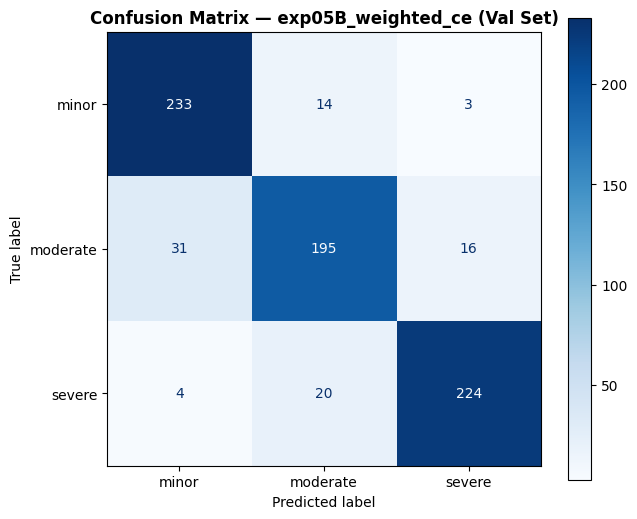

✅ exp05B_weighted_ce — val results saved to Drive.
   Val Macro F1: 0.88


In [12]:
ckpt=torch.load(os.path.join(EXP_DIR,'exp05B_weighted_ce','weights','best_model.pth'),map_location=DEVICE)
model_05b.load_state_dict(ckpt['model_state'])
train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
val_f1_05b=save_val_results('exp05B_weighted_ce',model_05b,val_loader,build_criterion('exp05B_weighted_ce'),optimizer_05b,history_05b,best_epoch_05b,best_val_f1_05b)
print(f'   Val Macro F1: {val_f1_05b}')


## 🟠 Section 10 — exp05C · Focal Loss (γ=2)

In [13]:
SUB_ID='exp05C_focal_loss'; sub_cfg=SUB_CONFIGS[SUB_ID]
with open(os.path.join(EXP_DIR,SUB_ID,'config.json'),'w') as f:
    json.dump({**BASE_CONFIG,**sub_cfg,'sub_id':SUB_ID},f,indent=2,default=str)

train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
model_05c=build_model(); optimizer_05c=build_optimizer(model_05c)
criterion=build_criterion(SUB_ID)
ckpt_path=os.path.join(EXP_DIR,SUB_ID,'weights','best_model.pth')

history_05c={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'train_f1':[],'val_f1':[]}
best_val_f1_05c=0.0; best_epoch_05c=0; patience_count=0
PATIENCE=BASE_CONFIG['early_stop_patience']; EPOCHS=BASE_CONFIG['epochs']

print(f'🚀 {SUB_ID} | loss: {sub_cfg["loss_name"]}')
print(f'{"Ep":>4}  {"T-Loss":>8}  {"T-F1":>7}  {"V-Loss":>8}  {"V-F1":>7}  {"Pat":>4}')
print('-'*50)

for epoch in range(EPOCHS):
    tr_loss,tr_acc,tr_f1,_,_=run_epoch(model_05c,train_loader,criterion,optimizer_05c,'train')
    vl_loss,vl_acc,vl_f1,_,_=run_epoch(model_05c,val_loader,  criterion,optimizer_05c,'val')
    for k,v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
                   [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]): history_05c[k].append(v)
    if vl_f1>best_val_f1_05c: best_val_f1_05c=vl_f1; best_epoch_05c=epoch; patience_count=0; save_checkpoint(model_05c,optimizer_05c,epoch,best_val_f1_05c,ckpt_path); flag='⭐'
    else: patience_count+=1; flag=''
    print(f'{epoch+1:4d}  {tr_loss:8.4f}  {tr_f1:7.4f}  {vl_loss:8.4f}  {vl_f1:7.4f}  {patience_count:4d}  {flag}')
    if patience_count>=PATIENCE: print(f'⏹️ Early stopping at epoch {epoch+1}'); break

print(f'\n✅ {SUB_ID} done. Best val F1: {best_val_f1_05c:.4f} (epoch {best_epoch_05c+1})')


🚀 exp05C_focal_loss | loss: FocalLoss(g=2)
  Ep    T-Loss     T-F1    V-Loss     V-F1   Pat
--------------------------------------------------
   1    0.2532   0.7019    0.2277   0.7376     0  ⭐
   2    0.1765   0.7901    0.1919   0.7644     0  ⭐
   3    0.1301   0.8422    0.1998   0.7992     0  ⭐
   4    0.1194   0.8575    0.1695   0.8080     0  ⭐
   5    0.0882   0.8929    0.2002   0.7851     1  
   6    0.0921   0.8914    0.2163   0.7810     2  
   7    0.0718   0.9156    0.1738   0.8338     0  ⭐
   8    0.0738   0.9133    0.1575   0.8506     0  ⭐
   9    0.0524   0.9310    0.1856   0.8519     0  ⭐
  10    0.0500   0.9385    0.2587   0.8348     1  
  11    0.0577   0.9311    0.2265   0.8635     0  ⭐
  12    0.0505   0.9416    0.1976   0.8560     1  
  13    0.0482   0.9419    0.1835   0.8593     2  
  14    0.0389   0.9494    0.1772   0.8717     0  ⭐
  15    0.0374   0.9561    0.2401   0.8402     1  
  16    0.0423   0.9512    0.2327   0.8452     2  
  17    0.0264   0.9629    0.204

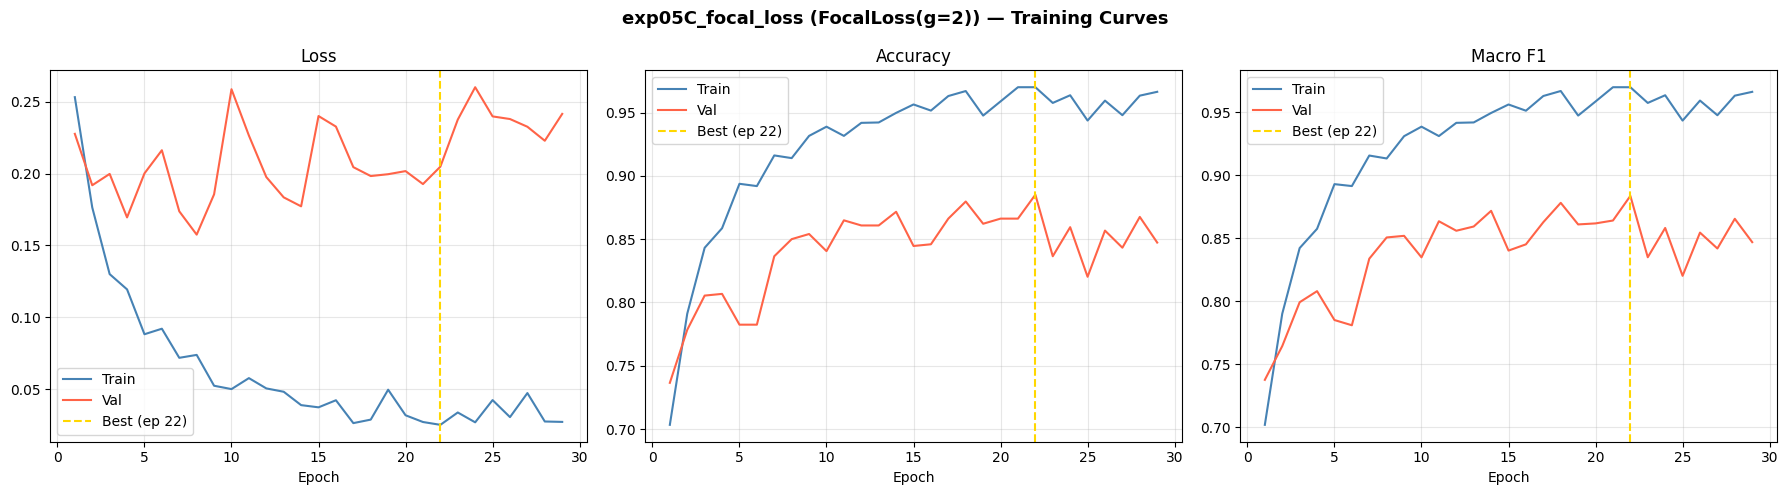


📋 exp05C_focal_loss — Classification Report (VAL SET):
              precision    recall  f1-score   support

       minor     0.8699    0.9360    0.9017       250
    moderate     0.8649    0.7934    0.8276       242
      severe     0.9197    0.9234    0.9215       248

    accuracy                         0.8851       740
   macro avg     0.8848    0.8843    0.8836       740
weighted avg     0.8849    0.8851    0.8841       740



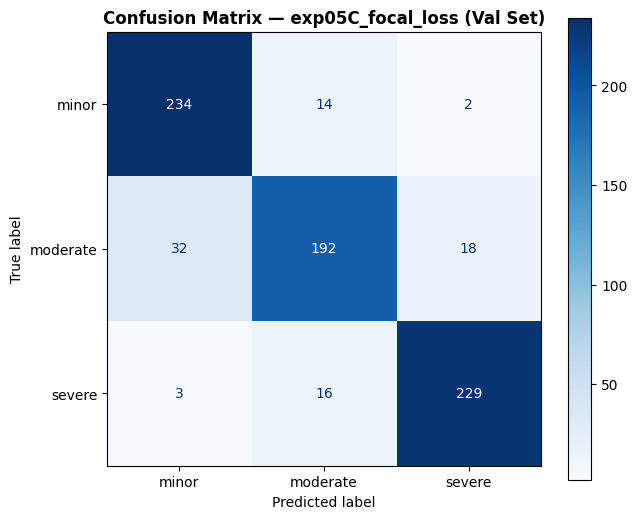

✅ exp05C_focal_loss — val results saved to Drive.
   Val Macro F1: 0.8836


In [14]:
ckpt=torch.load(os.path.join(EXP_DIR,'exp05C_focal_loss','weights','best_model.pth'),map_location=DEVICE)
model_05c.load_state_dict(ckpt['model_state'])
train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
val_f1_05c=save_val_results('exp05C_focal_loss',model_05c,val_loader,build_criterion('exp05C_focal_loss'),optimizer_05c,history_05c,best_epoch_05c,best_val_f1_05c)
print(f'   Val Macro F1: {val_f1_05c}')


## 🟣 Section 10D — exp05D · Label Smoothing CE (ε=0.1)

In [15]:
SUB_ID='exp05D_label_smoothing'; sub_cfg=SUB_CONFIGS[SUB_ID]
with open(os.path.join(EXP_DIR,SUB_ID,'config.json'),'w') as f:
    json.dump({**BASE_CONFIG,**sub_cfg,'sub_id':SUB_ID},f,indent=2,default=str)

train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
model_05d=build_model(); optimizer_05d=build_optimizer(model_05d)
criterion=build_criterion(SUB_ID)
ckpt_path=os.path.join(EXP_DIR,SUB_ID,'weights','best_model.pth')

history_05d={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'train_f1':[],'val_f1':[]}
best_val_f1_05d=0.0; best_epoch_05d=0; patience_count=0
PATIENCE=BASE_CONFIG['early_stop_patience']; EPOCHS=BASE_CONFIG['epochs']

print(f'🚀 {SUB_ID} | loss: {sub_cfg["loss_name"]}')
print(f'{"Ep":>4}  {"T-Loss":>8}  {"T-F1":>7}  {"V-Loss":>8}  {"V-F1":>7}  {"Pat":>4}')
print('-'*50)

for epoch in range(EPOCHS):
    tr_loss,tr_acc,tr_f1,_,_=run_epoch(model_05d,train_loader,criterion,optimizer_05d,'train')
    vl_loss,vl_acc,vl_f1,_,_=run_epoch(model_05d,val_loader,  criterion,optimizer_05d,'val')
    for k,v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
                   [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]): history_05d[k].append(v)
    if vl_f1>best_val_f1_05d: best_val_f1_05d=vl_f1; best_epoch_05d=epoch; patience_count=0; save_checkpoint(model_05d,optimizer_05d,epoch,best_val_f1_05d,ckpt_path); flag='⭐'
    else: patience_count+=1; flag=''
    print(f'{epoch+1:4d}  {tr_loss:8.4f}  {tr_f1:7.4f}  {vl_loss:8.4f}  {vl_f1:7.4f}  {patience_count:4d}  {flag}')
    if patience_count>=PATIENCE: print(f'⏹️ Early stopping at epoch {epoch+1}'); break

print(f'\n✅ {SUB_ID} done. Best val F1: {best_val_f1_05d:.4f} (epoch {best_epoch_05d+1})')


🚀 exp05D_label_smoothing | loss: LabelSmoothing(e=0.1)
  Ep    T-Loss     T-F1    V-Loss     V-F1   Pat
--------------------------------------------------
   1    0.7603   0.7091    0.7294   0.7295     0  ⭐
   2    0.6345   0.8041    0.8288   0.6919     1  
   3    0.5542   0.8607    0.6346   0.8181     0  ⭐
   4    0.5136   0.8849    0.7074   0.8072     1  
   5    0.4755   0.9091    0.6230   0.8517     0  ⭐
   6    0.4465   0.9220    0.6354   0.8358     1  
   7    0.4226   0.9381    0.5839   0.8705     0  ⭐
   8    0.4038   0.9531    0.5965   0.8750     0  ⭐
   9    0.3905   0.9582    0.5747   0.8732     1  
  10    0.3757   0.9701    0.5596   0.8841     0  ⭐
  11    0.3718   0.9705    0.5476   0.8782     1  
  12    0.3726   0.9672    0.5921   0.8633     2  
  13    0.3599   0.9751    0.5722   0.8755     3  
  14    0.3569   0.9790    0.5617   0.8850     0  ⭐
  15    0.3573   0.9726    0.5867   0.8734     1  
  16    0.3603   0.9726    0.5713   0.8740     2  
  17    0.3530   0.976

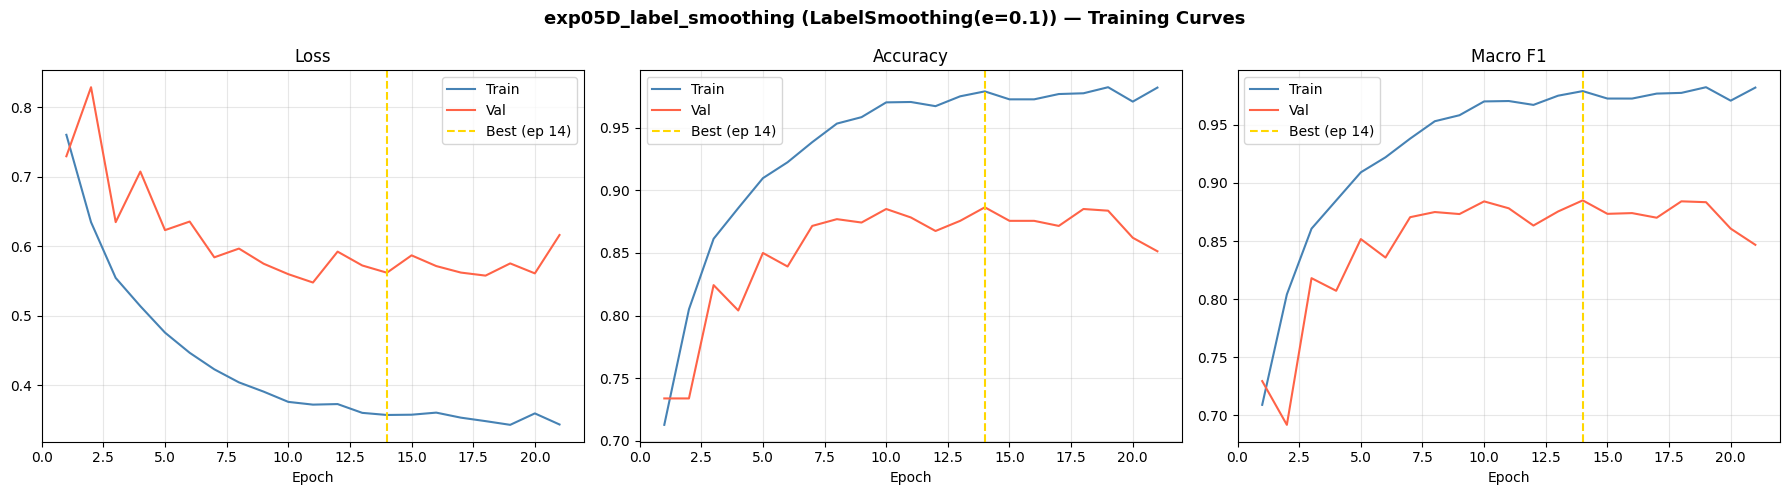


📋 exp05D_label_smoothing — Classification Report (VAL SET):
              precision    recall  f1-score   support

       minor     0.8541    0.9600    0.9040       250
    moderate     0.8767    0.7934    0.8330       242
      severe     0.9333    0.9032    0.9180       248

    accuracy                         0.8865       740
   macro avg     0.8880    0.8855    0.8850       740
weighted avg     0.8880    0.8865    0.8855       740



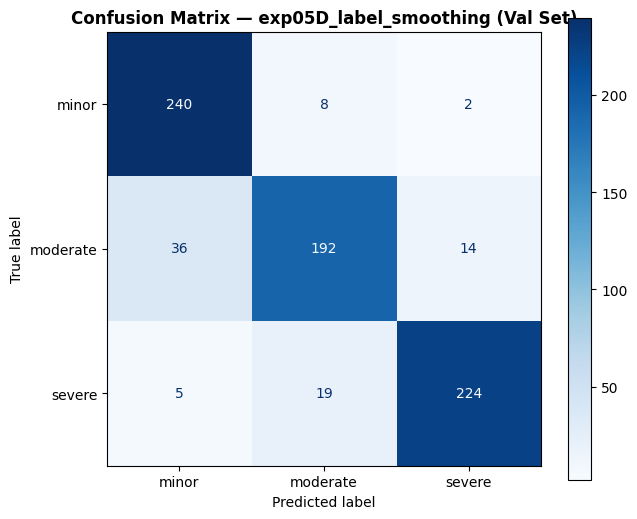

✅ exp05D_label_smoothing — val results saved to Drive.
   Val Macro F1: 0.885


In [16]:
ckpt=torch.load(os.path.join(EXP_DIR,'exp05D_label_smoothing','weights','best_model.pth'),map_location=DEVICE)
model_05d.load_state_dict(ckpt['model_state'])
train_loader,val_loader,test_loader,train_ds,val_ds,test_ds=build_dataloaders()
val_f1_05d=save_val_results('exp05D_label_smoothing',model_05d,val_loader,build_criterion('exp05D_label_smoothing'),optimizer_05d,history_05d,best_epoch_05d,best_val_f1_05d)
print(f'   Val Macro F1: {val_f1_05d}')


## 📊 Section 11 — Winner Selection & Final Test Evaluation

📊 Val Macro F1 ranking — used to select winner:
   1. exp05D_label_smoothing: 0.8850  (LabelSmoothing(e=0.1))  ← WINNER
   2. exp05A_cross_entropy: 0.8842  (CrossEntropy)
   3. exp05C_focal_loss: 0.8836  (FocalLoss(g=2))
   4. exp05B_weighted_ce: 0.8800  (WeightedCE)

🏆 Winner: exp05D_label_smoothing (val F1 = 0.8850)

🏆 Final test evaluation — winner: exp05D_label_smoothing (LabelSmoothing(e=0.1))
   (Test set used for the first and only time)

📋 exp05D_label_smoothing — Classification Report (TEST SET):
              precision    recall  f1-score   support

       minor     0.9104    0.9683    0.9385       252
    moderate     0.8833    0.8797    0.8815       241
      severe     0.9615    0.9036    0.9317       249

    accuracy                         0.9178       742
   macro avg     0.9184    0.9172    0.9172       742
weighted avg     0.9188    0.9178    0.9177       742



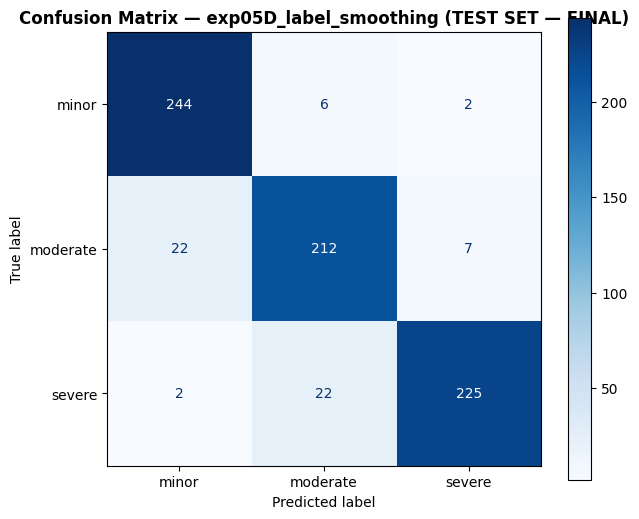

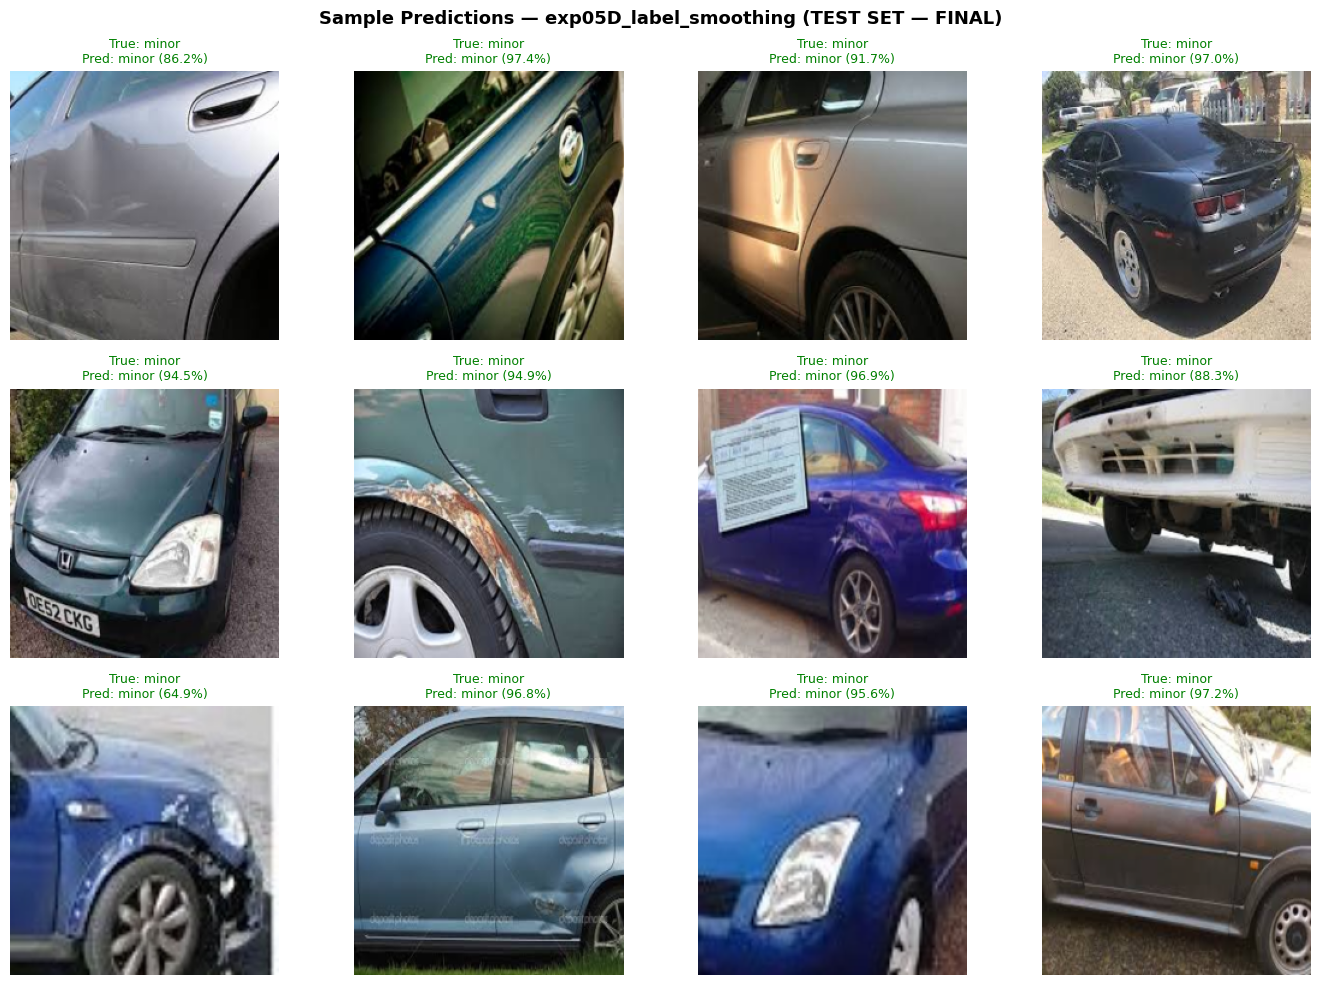


✅ Final test results saved for exp05D_label_smoothing.

📊 Full comparison table:
            Experiment                  Loss Val Macro F1   Test Macro F1         Note
                 exp00          CrossEntropy            —          0.7609   current CE
                 exp01          CrossEntropy            —          0.9100   current CE
                exp02E          CrossEntropy            —           ~0.91   current CE
                exp03B          CrossEntropy            —          0.9018 stronger aug
exp05D_label_smoothing LabelSmoothing(e=0.1)        0.885          0.9172     🏆 WINNER
  exp05A_cross_entropy          CrossEntropy       0.8842 (not evaluated)             
     exp05C_focal_loss        FocalLoss(g=2)       0.8836 (not evaluated)             
    exp05B_weighted_ce            WeightedCE         0.88 (not evaluated)             

✅ Saved → /content/drive/MyDrive/Severity_Model/exp05_loss_function/comparison_table.csv


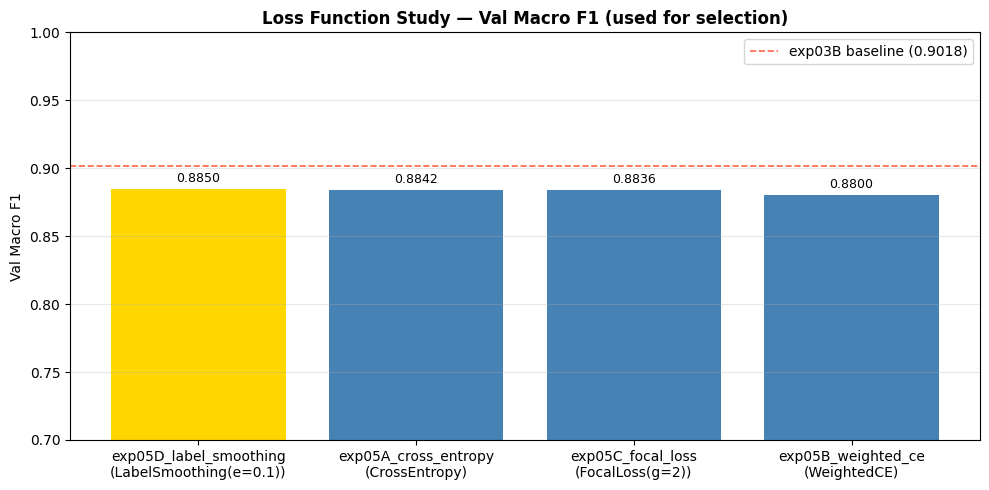

✅ Chart saved.


In [17]:
val_results={
    'exp05A_cross_entropy' : val_f1_05a,
    'exp05B_weighted_ce'   : val_f1_05b,
    'exp05C_focal_loss'    : val_f1_05c,
    'exp05D_label_smoothing': val_f1_05d,
}

print('📊 Val Macro F1 ranking — used to select winner:')
sorted_results=sorted(val_results.items(),key=lambda x:x[1],reverse=True)
for rank,(sub,f1) in enumerate(sorted_results,1):
    marker='  ← WINNER' if rank==1 else ''
    print(f'   {rank}. {sub}: {f1:.4f}  ({SUB_CONFIGS[sub]["loss_name"]}){marker}')

WINNER_ID=sorted_results[0][0]
print(f'\n🏆 Winner: {WINNER_ID} (val F1 = {val_results[WINNER_ID]:.4f})')

winner_models    ={'exp05A_cross_entropy':model_05a,'exp05B_weighted_ce':model_05b,
                   'exp05C_focal_loss':model_05c,'exp05D_label_smoothing':model_05d}
winner_optimizers={'exp05A_cross_entropy':optimizer_05a,'exp05B_weighted_ce':optimizer_05b,
                   'exp05C_focal_loss':optimizer_05c,'exp05D_label_smoothing':optimizer_05d}
winner_model    =winner_models[WINNER_ID]; winner_optimizer=winner_optimizers[WINNER_ID]
ckpt=torch.load(os.path.join(EXP_DIR,WINNER_ID,'weights','best_model.pth'),map_location=DEVICE)
winner_model.load_state_dict(ckpt['model_state'])
train_loader,_,test_loader_final,_,_,test_ds_final=build_dataloaders()
test_f1_winner=run_final_test_eval(WINNER_ID,winner_model,winner_optimizer,
                                   test_loader_final,build_criterion(WINNER_ID),test_ds_final)

# Full comparison table
rows=[]
prev=[('exp00','Adam 1e-3','current CE','0.7609'),
      ('exp01','Adam 1e-4','current CE','0.9100'),
      ('exp02E','AdamW 1e-4 bs=32','current CE','~0.91'),
      ('exp03B','AdamW 1e-4 bs=32','stronger aug','0.9018')]
for exp,opt,note,tf1 in prev:
    rows.append({'Experiment':exp,'Loss':'CrossEntropy','Val Macro F1':'—','Test Macro F1':tf1,'Note':note})
for sub,vf1 in sorted_results:
    is_w=(sub==WINNER_ID)
    rows.append({'Experiment':sub,'Loss':SUB_CONFIGS[sub]['loss_name'],
                 'Val Macro F1':round(vf1,4),
                 'Test Macro F1':round(test_f1_winner,4) if is_w else '(not evaluated)',
                 'Note':'🏆 WINNER' if is_w else ''})
comp=pd.DataFrame(rows); csv_path=os.path.join(EXP_DIR,'comparison_table.csv')
comp.to_csv(csv_path,index=False); print('\n📊 Full comparison table:'); print(comp.to_string(index=False))
print(f'\n✅ Saved → {csv_path}')

# Bar chart
subs=[r[0] for r in sorted_results]; vf1s=[r[1] for r in sorted_results]
xlabels=[f'{s}\n({SUB_CONFIGS[s]["loss_name"]})' for s in subs]
colors=['gold' if s==WINNER_ID else 'steelblue' for s in subs]
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.bar(xlabels,vf1s,color=colors)
ax.set_ylim(0.7,1.0); ax.set_ylabel('Val Macro F1')
ax.set_title('Loss Function Study — Val Macro F1 (used for selection)',fontweight='bold')
ax.axhline(0.9018,color='tomato',linestyle='--',linewidth=1.2,label='exp03B baseline (0.9018)')
for bar,val in zip(bars,vf1s):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,f'{val:.4f}',ha='center',va='bottom',fontsize=9)
ax.legend(); ax.grid(axis='y',alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(EXP_DIR,'val_comparison_chart.png'),dpi=150,bbox_inches='tight'); plt.show()
print('✅ Chart saved.')


## 📝 Section 12 — Experiment Conclusion

> Fill in manually after all sub-experiments and the final test evaluation complete.

| Field | Value |
|---|---|
| **Winner (by val F1)** | *(auto-selected in Section 11)* |
| **Winner Loss Function** | *(fill in)* |
| **Winner Val Macro F1** | *(fill in)* |
| **Winner Test Macro F1** | *(fill in)* |
| **Did changing loss improve Macro F1?** | *(Yes / No / Marginal)* |
| **Which loss improved difficult classes?** | *(fill in)* |
| **Did weighted CE improve moderate recall?** | *(Yes / No)* |
| **Did focal loss reduce boundary confusion?** | *(Yes / No)* |
| **Did label smoothing improve generalisation?** | *(Yes / No)* |
| **Is improvement large enough to justify new loss?** | *(Yes / No / Marginal)* |
| **Loss to carry forward** | *(CrossEntropy / WeightedCE / FocalLoss / LabelSmoothing)* |

### Analysis questions
1. Did changing the loss improve performance?
2. Which loss improved the difficult classes?
3. Did weighted losses improve recall but reduce precision?
4. Did focal loss reduce confusion between severity levels?
5. Did label smoothing improve generalisation?
6. Is the improvement large enough to justify using the new loss?

### Evaluation protocol
- **Val set**: used after each sub-experiment to rank configurations
- **Test set**: used exactly once on the val-selected winner

### Outcome guide
| Outcome | Interpretation | Next step |
|---|---|---|
| Weighted/Focal/Smooth > CE | Loss change improves difficult classes or generalisation | Carry winning loss to exp06 |
| All losses ≈ equal | Loss function not the bottleneck | Stick with standard CE |
| Alternative < CE | Simpler loss is best for this dataset | Keep CE, move on |

#Summary Findings
---
This experiment evaluated the effect of different loss functions on the fine-tuned ResNet50 severity estimation model. All training settings were fixed, and only the loss function was modified.

The results showed that modifying the loss function can improve model generalization, with label smoothing achieving the strongest performance among the evaluated approaches. This suggests that the severity estimation task contains inherent ambiguity between visually similar damage levels, and reducing model overconfidence helps create more robust decision boundaries.

Weighted Cross Entropy did not provide significant improvement, likely because the dataset classes were relatively balanced. Focal Loss also did not outperform the baseline, indicating that the main challenge is not severe class imbalance but the difficulty of distinguishing between visually similar severity levels.

Across all experiments, the largest improvement came from full fine-tuning of the pretrained ResNet50 backbone. Further improvements from optimization, augmentation, and loss modification were smaller, suggesting that the current limitation is mainly related to dataset size and severity label complexity.

The final selected model configuration is:

- ResNet50 pretrained on ImageNet
- Full fine-tuning
- Input size: 224×224
- AdamW optimizer
- Learning rate: 1e-4
- Batch size: 32
- Strong augmentation
- Label smoothing cross entropy loss

This model will be used for integration into the complete damage assessment pipeline.